In [2]:
!pip -q install yfinance deap


In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import random

from deap import base, creator, tools, algorithms


In [6]:
import yfinance as yf

data = yf.download(
    "^NSEI",
    start="2018-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data = data.dropna()

print(data.head())
print("Number of rows:", len(data))


[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2018-01-02  10442.200195  10495.200195  10404.650391  10477.549805  153400
2018-01-03  10443.200195  10503.599609  10429.549805  10482.650391  167300
2018-01-04  10504.799805  10513.000000  10441.450195  10469.400391  174900
2018-01-05  10558.849609  10566.099609  10520.099609  10534.250000  180900
2018-01-08  10623.599609  10631.200195  10588.549805  10591.700195  169000
Number of rows: 1972


In [8]:
def trading_strategy(data, fast_ma, slow_ma):

    df = data.copy()

    # Moving averages
    df["Fast_MA"] = df["Close"].rolling(fast_ma).mean()
    df["Slow_MA"] = df["Close"].rolling(slow_ma).mean()

    # Trading signal
    df["Signal"] = 0
    df.loc[df["Fast_MA"] > df["Slow_MA"], "Signal"] = 1

    # Daily market return
    df["Market_Return"] = df["Close"].pct_change()

    # Strategy return
    df["Strategy_Return"] = (
        df["Signal"].shift(1) * df["Market_Return"]
    )

    df = df.dropna()

    return df


In [9]:
result = trading_strategy(data, 20, 100)

print(result[[
    "Close",
    "Fast_MA",
    "Slow_MA",
    "Signal",
    "Strategy_Return"
]].tail())


Price              Close       Fast_MA       Slow_MA Signal Strategy_Return
Ticker             ^NSEI                                                   
Date                                                                       
2025-12-24  26142.099609  26015.795117  25380.461621      1       -0.001339
2025-12-26  26042.300781  26007.132617  25393.201133      1       -0.003818
2025-12-29  25942.099609  25994.090137  25406.968633      1       -0.003848
2025-12-30  25938.849609  25982.245117  25419.129629      1       -0.000125
2025-12-31  26129.599609  25987.115137  25433.930117      1        0.007354


In [10]:
from deap import base, creator, tools, algorithms
import random

# Create fitness and individual
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Generate random MA values
toolbox.register("fast_ma", random.randint, 10, 50)
toolbox.register("slow_ma", random.randint, 50, 200)

# Create an individual
toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    (toolbox.fast_ma, toolbox.slow_ma),
    n=1
)

# Create population
toolbox.register(
    "population",
    tools.initRepeat,
    list,
    toolbox.individual
)


In [12]:
def fitness_function(individual):

    fast_ma = individual[0]
    slow_ma = individual[1]

    # Fast MA must be smaller than Slow MA
    if fast_ma >= slow_ma:
        return (-1000,)

    result = trading_strategy(data, fast_ma, slow_ma)

    returns = result["Strategy_Return"]

    # Avoid invalid results
    if returns.std() == 0:
        return (-1000,)

    # Sharpe Ratio
    sharpe = (
        returns.mean() / returns.std()
    ) * np.sqrt(252)

    return (sharpe,)


toolbox.register(
    "evaluate",
    fitness_function
)


In [13]:
# Crossover: combine two strategies
toolbox.register("mate", tools.cxTwoPoint)

# Mutation: randomly change parameters
toolbox.register(
    "mutate",
    tools.mutUniformInt,
    low=[10, 50],
    up=[50, 200],
    indpb=0.2
)

# Selection: choose better strategies
toolbox.register(
    "select",
    tools.selTournament,
    tournsize=3
)


In [14]:
population = toolbox.population(n=100)

NGEN = 20
CXPB = 0.7
MUTPB = 0.2

for generation in range(NGEN):

    offspring = algorithms.varAnd(
        population,
        toolbox,
        CXPB,
        MUTPB
    )

    # Calculate fitness
    for individual in offspring:
        individual.fitness.values = toolbox.evaluate(individual)

    # Select best individuals
    population = toolbox.select(
        offspring,
        k=len(population)
    )

    best = tools.selBest(population, 1)[0]

    print(
        f"Generation {generation + 1}: "
        f"Fast MA = {best[0]}, "
        f"Slow MA = {best[1]}, "
        f"Sharpe = {best.fitness.values[0]:.2f}"
    )


Generation 1: Fast MA = 16, Slow MA = 62, Sharpe = 1.19
Generation 2: Fast MA = 12, Slow MA = 64, Sharpe = 1.25
Generation 3: Fast MA = 12, Slow MA = 64, Sharpe = 1.25
Generation 4: Fast MA = 12, Slow MA = 64, Sharpe = 1.25
Generation 5: Fast MA = 12, Slow MA = 64, Sharpe = 1.25
Generation 6: Fast MA = 12, Slow MA = 64, Sharpe = 1.25
Generation 7: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 8: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 9: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 10: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 11: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 12: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 13: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 14: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 15: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 16: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 17: Fast MA = 11, Slow MA = 64, Sharpe = 1.29
Generation 18: Fast MA = 11, Slow MA = 6

In [15]:
# Get the best solution found by the Genetic Algorithm

best_individual = tools.selBest(population, 1)[0]

best_fast_ma = best_individual[0]
best_slow_ma = best_individual[1]
best_sharpe = best_individual.fitness.values[0]

print("Best Fast MA:", best_fast_ma)
print("Best Slow MA:", best_slow_ma)
print("Best Sharpe Ratio:", best_sharpe)

Best Fast MA: 11
Best Slow MA: 64
Best Sharpe Ratio: 1.28775397850403


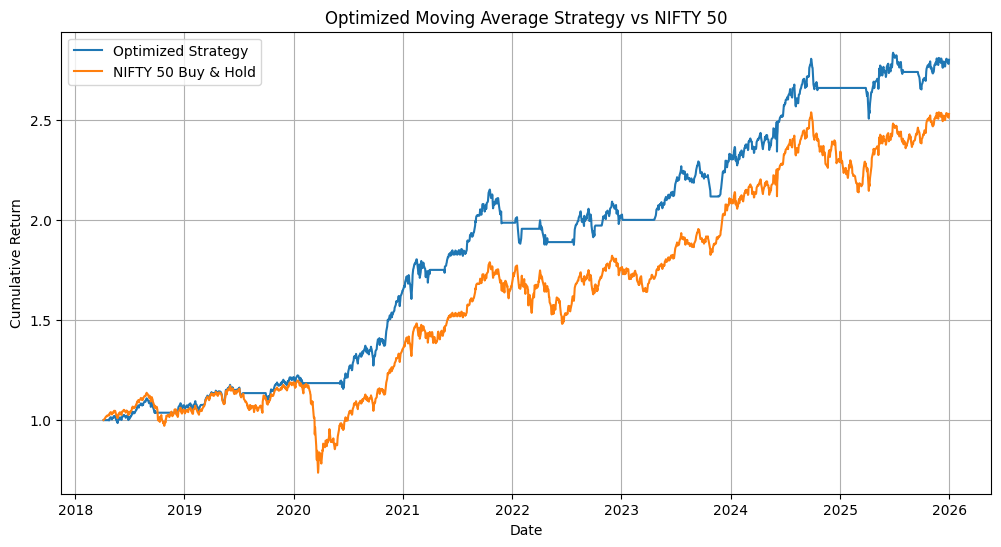

In [16]:
# Apply the optimized strategy
optimized_result = trading_strategy(
    data,
    best_fast_ma,
    best_slow_ma
)

# Calculate cumulative returns
optimized_result["Cumulative_Strategy"] = (
    1 + optimized_result["Strategy_Return"]
).cumprod()

optimized_result["Cumulative_Market"] = (
    1 + optimized_result["Market_Return"]
).cumprod()

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    optimized_result.index,
    optimized_result["Cumulative_Strategy"],
    label="Optimized Strategy"
)

plt.plot(
    optimized_result.index,
    optimized_result["Cumulative_Market"],
    label="NIFTY 50 Buy & Hold"
)

plt.title("Optimized Moving Average Strategy vs NIFTY 50")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Calculate final cumulative returns
strategy_final = optimized_result["Cumulative_Strategy"].iloc[-1]
market_final = optimized_result["Cumulative_Market"].iloc[-1]

# Total returns
strategy_return = (strategy_final - 1) * 100
market_return = (market_final - 1) * 100

# Maximum drawdown
strategy_drawdown = (
    optimized_result["Cumulative_Strategy"] /
    optimized_result["Cumulative_Strategy"].cummax()
    - 1
)

max_drawdown = strategy_drawdown.min() * 100

print("===== PERFORMANCE RESULTS =====")
print(f"Optimized Strategy Return: {strategy_return:.2f}%")
print(f"NIFTY 50 Buy & Hold Return: {market_return:.2f}%")
print(f"Maximum Drawdown: {max_drawdown:.2f}%")
print(f"Best Fast MA: {best_fast_ma}")
print(f"Best Slow MA: {best_slow_ma}")
print(f"Sharpe Ratio: {best_sharpe:.4f}")

===== PERFORMANCE RESULTS =====
Optimized Strategy Return: 180.17%
NIFTY 50 Buy & Hold Return: 153.07%
Maximum Drawdown: -12.85%
Best Fast MA: 11
Best Slow MA: 64
Sharpe Ratio: 1.2878


In [18]:
# Final Results Summary

results = {
    "Metric": [
        "Best Fast Moving Average",
        "Best Slow Moving Average",
        "Optimized Strategy Return",
        "NIFTY 50 Buy & Hold Return",
        "Maximum Drawdown",
        "Sharpe Ratio"
    ],
    "Value": [
        f"{best_fast_ma} days",
        f"{best_slow_ma} days",
        f"{strategy_return:.2f}%",
        f"{market_return:.2f}%",
        f"{max_drawdown:.2f}%",
        f"{best_sharpe:.4f}"
    ]
}

results_df = pd.DataFrame(results)
display(results_df)

,Metric,Value
0,Best Fast Moving Average,11 days
1,Best Slow Moving Average,64 days
2,Optimized Strategy Return,180.17%
3,NIFTY 50 Buy & Hold Return,153.07%
4,Maximum Drawdown,-12.85%
5,Sharpe Ratio,1.2878
